<a href="https://colab.research.google.com/github/Reape4er/neural_network-2/blob/main/%D0%9D%D0%B5%D0%B9%D1%80%D0%BE%D1%81%D0%B5%D1%82%D0%B8_%D0%BF%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D0%BA%D0%B0_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическая работа №2. Использование глубоких нейронных сетей для решения задач регрессии и классификации



**Ссылка на код с пары:**
https://colab.research.google.com/drive/18EM8mrpURStkmbxWjZybWbWh23Si5b4A?usp=sharing


## Задание №1. Обучение модели ИНС для решения задачи регрессии



Постройте глубокую нейронную сеть для предсказания цен на недвижимость в городе Бостон, используя датасет датасет boston_housing_price

[Описание датасета](https://www.hackersrealm.net/post/boston-house-price-prediction-analysis-using-python)

#### 1.1. Загружаем исходные данные:

In [ ]:
import pandas as pd
import numpy as np

data_url = "https://github.com/meet-sapu/BOSTON-DATASET/raw/refs/heads/master/boston%20dataset/boston.xls"
raw_df = pd.read_excel(data_url, header=0)
data = raw_df.iloc[:,:-1]
target = raw_df["MV"]


In [ ]:
display(pd.DataFrame(data))

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PT,B,LSTAT
0,0.00632,18.0,2.31,0,0.538,6.575,65.199997,4.0900,1,296,15.300000,396.899994,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.900002,4.9671,2,242,17.799999,396.899994,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.099998,4.9671,2,242,17.799999,392.829987,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.799999,6.0622,3,222,18.700001,394.630005,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.200001,6.0622,3,222,18.700001,396.899994,5.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.099998,2.4786,1,273,21.000000,391.989990,9.67
502,0.04527,0.0,11.93,0,0.573,6.120,76.699997,2.2875,1,273,21.000000,396.899994,9.08
503,0.06076,0.0,11.93,0,0.573,6.976,91.000000,2.1675,1,273,21.000000,396.899994,5.64
504,0.10959,0.0,11.93,0,0.573,6.794,89.300003,2.3889,1,273,21.000000,393.450012,6.48


In [ ]:
target

,MV
0,24.000000
1,21.600000
2,34.700001
3,33.400002
4,36.200001
...,...
501,22.400000
502,20.600000
503,23.900000
504,22.000000


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.2, random_state=0)
X_train.shape, X_test.shape

((404, 13), (102, 13))

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()  # Стандартизация по среднему и стандартному отклонению
# scaler = MinMaxScaler()  # Масштабирование в диапазон 0-1

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# Сохранение модели scaler
import pickle

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

#### 1.2. Проектируем архитектуру для этой задачи

In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Input
from tensorflow.keras.optimizers import Adam


# model = Sequential([
#     Dense(64, input_shape=(13,), activation='relu'),
#     Dense(32,  activation='relu'),
#     Dense(16,  activation='relu'),
#     Dense(8,  activation='relu'),
#     Dense(1, activation='linear')
# ])
model = Sequential([
    Dense(256, input_shape=(13,), activation='relu'),
    Dense(128,  activation='relu'),
    Dense(1, activation='linear')
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_23 (Dense)                │ (None, 256)            │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,609 (143.00 KB)

 Trainable params: 36,609 (143.00 KB)

 Non-trainable params: 0 (0.00 B)


#### 1.3. Компилируем модель ИНС

Подберите нужную функцию потерь и метрику.

In [ ]:
## Параметры обучения
INIT_LR = 0.0001
EPOCHS = 80

opt = Adam(learning_rate=INIT_LR)
model.compile(loss="MSE", optimizer=opt, metrics=["MAE"])

#### 1.4. Обучаем модель ИНС

In [ ]:
H = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS, batch_size=4
)

Epoch 1/80
101/101 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - MAE: 21.3448 - loss: 541.9284 - val_MAE: 19.6549 - val_loss: 469.1290
Epoch 2/80
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - MAE: 18.4233 - loss: 423.7583 - val_MAE: 16.1604 - val_loss: 340.4327
Epoch 3/80
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - MAE: 14.1888 - loss: 272.2895 - val_MAE: 11.5627 - val_loss: 201.8848
Epoch 4/80
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - MAE: 9.4100 - loss: 137.7404 - val_MAE: 7.8285 - val_loss: 112.2150
Epoch 5/80
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MAE: 6.2993 - loss: 70.7986 - val_MAE: 6.4056 - val_loss: 80.9747
Epoch 6/80
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - MAE: 5.1163 - loss: 47.3519 - val_MAE: 5.7891 - val_loss: 66.9124
Epoch 7/80
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - MAE: 4.3917 - loss: 35.9955 - val_MAE: 5.4155 - val_loss: 57.6029
Epoch 8/80
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - MAE: 3.9526 - loss: 29.3207 - val_MAE: 5.1471 - val_loss: 52.1771
Epoch 9/80
101/101 ━━━━━━

#### 1.6. Делаем предсказания на тестовых данных

In [ ]:
preds = model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


#### 1.7. Вычисляем метрику качества на тестовых данных

In [ ]:
from sklearn.metrics import mean_absolute_error

print(mean_absolute_error(preds, y_test))

3.051141701374962


#### 1.8. Строим график обучения

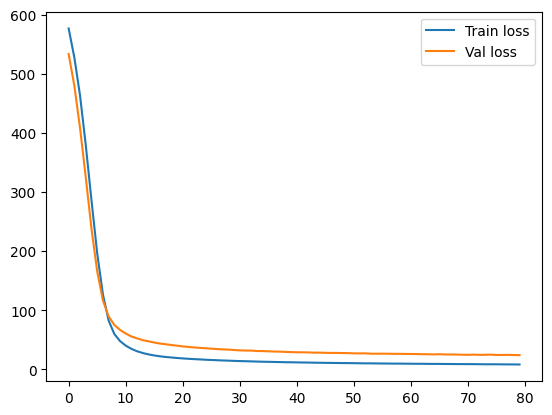

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.plot(H.history['loss'], label='Train loss')
plt.plot(H.history['val_loss'], label='Val loss')
plt.legend()
plt.show()

#### 1.9. Построение графического интерфейса в Gradio Проверка обученной модели пользовательскими данными

In [ ]:
!pip install gradio

In [ ]:
def preprocess_input(features, scale_model="scaler.pkl"):

  """
  Функция преобразует входные данные в формат,
  подходящий для модели машинного обучения.

  Args:
      features: Список или массив с входными признаками.
      scale_model: Путь к файлу с сохраненной моделью масштабирования.

  Returns:
      Преобразованный массив признаков.
  """

  try:
    # Преобразование в NumPy массив
    features = np.array(features)

    # Проверка на пустой массив
    if not features.size:
      raise ValueError("Пустой массив признаков!")

    # Изменение размерности массива (8,) -> (1, 8)
    features = features.reshape(1, -1)

    # Загрузка модели масштабирования
    with open(scale_model, "rb") as f:
      scaler = pickle.load(f)

    # Масштабирование признаков
    features = scaler.transform(features)

  except Exception as e:
    raise ValueError(f"Ошибка при предобработке: {e}")

  return features
def predict_price(*features):

  """
  Функция прогнозирует цену на основе предобработанных
  входных признаков.

  Args:
      features: Список или массив с входными признаками.

  Returns:
      Прогнозируемая цена (в долларах).
  """

  try:
    # Предобработка входных признаков
    features = preprocess_input(features)

    # Прогнозирование цены
    prediction = model.predict(features, verbose=0)

    # Проверка на ошибки прогнозирования
    if np.isnan(prediction).any():
      raise ValueError("Ошибка при прогнозировании: NaN")

  except Exception as e:
    raise ValueError(f"Ошибка при прогнозировании: {e}")

  # Возвращение прогнозируемой цены
  # (умножение на 1000 для отображения в тысячах долларов)
  return f"{prediction[0][0]}"

In [ ]:
import gradio as gr

# Интерфейс Gradio
interface = gr.Interface(
    fn=predict_price,
    inputs=[
        gr.Slider(minimum=0, maximum=100, step=0.1, label="CRIM (per capita crime rate by town)"),
        gr.Slider(minimum=0, maximum=100, step=0.1, label="ZN (proportion of residential land zoned for lots over 25,000 sq.ft.)"),
        gr.Slider(minimum=0, maximum=100, step=0.1, label="INDUS (proportion of non-retail business acres per town)"),
        gr.Slider(minimum=0, maximum=1, step=1, label="CHAS (Charles River dummy variable)"),
        gr.Slider(minimum=0, maximum=1, step=0.01, label="NOX (nitric oxides concentration)"),
        gr.Slider(minimum=3, maximum=9, step=0.1, label="RM (average number of rooms per dwelling)"),
        gr.Slider(minimum=0, maximum=100, step=0.1, label="AGE (proportion of owner-occupied units built prior to 1940)"),
        gr.Slider(minimum=1, maximum=12, step=0.1, label="DIS (weighted distances to five Boston employment centres)"),
        gr.Slider(minimum=1, maximum=24, step=1, label="RAD (index of accessibility to radial highways)"),
        gr.Slider(minimum=100, maximum=1000, step=10, label="TAX (full-value property-tax rate per $10,000)"),
        gr.Slider(minimum=12, maximum=23, step=0.1, label="PTRATIO (pupil-teacher ratio by town)"),
        gr.Slider(minimum=0, maximum=400, step=1, label="B (1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town)"),
        gr.Slider(minimum=0, maximum=100, step=0.1, label="LSTAT (% lower status of the population)"),
    ],
    outputs=gr.Text(label="Predicted Price ($)"),
    title="Предсказание MEDV (Median value of owner-occupied homes)",
    description="Введите значения для каждого параметра, чтобы предсказать MEDV."
)

#### 2. Проверка обученной модели пользовательскими данными

In [ ]:
# Запуск интерфейса
interface.launch(debug=False, share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7a74ef509d672855bd.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Задание №2.Обучение модели ИНС для решения задачи классификации



Порядок работы:

* 1. Собрать датасет из изображений, соответствующих не менее, чем 3 классам объектов (в
примере с пары были кошки, собаки и панды).


- 2. Для каждого класса должно быть собрано не менее 1000 изображений. Количество
изображений для каждого класса должно быть одинаковым.
Готовые датасеты можно скачать отсюда: https://www.kaggle.com/


- 3. Обучить модель глубокой нейронной сети для решения задачи классификации
изображений, по выбранным Вами классам. (В качестве примера приведён код с пары)
В конечном итоге Вы должны сохранить обученную модель для классификации
изображений, соответствующих тем классам, которые Вы выбрали, а затем воспользоваться этой моделью для предсказания классов на пользовательских изображениях.



> При выполнении заданий пробуйте использовать разные функции потерь,
методы оптимизации, функции активации и метрики ошибок.

### 1. Устанавливаем зависимости:

In [1]:
# Импортируем LabelBinarizer для преобразования текстовых меток в векторы
# (например, "кошка" -> [1, 0, 0], "собака" -> [0, 1, 0], "панда" -> [0, 0, 1])
from sklearn.preprocessing import LabelBinarizer

# Импортируем train_test_split для разделения данных на обучающую и тестовую выборки
from sklearn.model_selection import train_test_split

# Импортируем classification_report для оценки качества классификации
from sklearn.metrics import classification_report

# Импортируем Sequential для создания последовательной модели нейронной сети
from keras.models import Sequential

# Импортируем Dense для создания плотных слоев нейронной сети
from keras.layers import Dense

# Импортируем SGD и Adam для оптимизации обучения нейронной сети
from keras.optimizers import SGD, Adam

# Импортируем paths из imutils для удобной работы с путями к изображениям
from imutils import paths

# Импортируем pyplot из matplotlib для визуализации данных
import matplotlib.pyplot as plt

# Импортируем numpy для работы с массивами данных
import numpy as np

# Импортируем random для генерации случайных чисел
import random

# Импортируем pickle для сериализации и десериализации данных
import pickle

# Импортируем cv2 для работы с изображениями
import cv2

# Импортируем os для работы с файловой системой
import os

# Импортируем cv2_imshow из google.colab.patches для отображения изображений в Colab
from google.colab.patches import cv2_imshow

### 2. Загружаем набор данных:

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alessiocorrado99/animals10")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'animals10' dataset.
Path to dataset files: /kaggle/input/animals10


### 3. Указываем путь к набору данных:

In [3]:
!ls $path

raw-img  translate.py


### 4. Загружаем набор данных и формируем общую выборку:

In [3]:
import multiprocessing
from tqdm import tqdm

# Загрузка и подготовка данных
imagePaths = sorted(list(paths.list_images(f"{path}/raw-img")))
random.shuffle(imagePaths)

def process_single_image(imagePath):
    try:
        image = cv2.imread(imagePath)
        image = cv2.resize(image, (64, 64)).flatten()
        label = imagePath.split(os.path.sep)[-2]
        return image, label
    except Exception:
        return None

data, labels_str = [], []

# Use multiprocessing for parallel processing
# Use tqdm for a progress bar
num_processes = multiprocessing.cpu_count() # Get the number of CPU cores
print(f"Using {num_processes} processes for image loading and preprocessing.")

with multiprocessing.Pool(processes=num_processes) as pool:
    # Use imap_unordered to yield results as they are ready, which is good for tqdm
    for result in tqdm(pool.imap_unordered(process_single_image, imagePaths), total=len(imagePaths), desc="Processing images"):
        if result is not None:
            image_data, label = result
            data.append(image_data)
            labels_str.append(label)


Using 2 processes for image loading and preprocessing.


Processing images: 100%|██████████| 26179/26179 [01:48<00:00, 241.92it/s]


In [6]:
print(len(imagePaths))
print(len(data))
print(len(labels_str))

26179
26179
26179


#### 4.1. Нормализуем данные:

Масштабируем интенсивности пикселей в диапазон [0, 1], а также преобразуем данные в массивы NumPy для повышения производительности


In [4]:
data = np.array(data, dtype="float") / 255.0
labels_str = np.array(labels_str)

In [5]:
# Создаем объект LabelBinarizer
lb = LabelBinarizer()

# Преобразуем строковые метки в бинарный формат
binary_labels = lb.fit_transform(labels_str)

# Выводим результат
print(binary_labels.shape)
print(binary_labels)
display(binary_labels)

(26179, 10)
[[0 0 0 ... 0 0 1]
 [0 0 0 ... 1 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 1 0]
 [0 0 0 ... 0 0 0]
 [1 0 0 ... 0 0 0]]


array([[0, 0, 0, ..., 0, 0, 1],
       [0, 0, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 1, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0]])

#### 4.2. Формируем обучающую и валидационную выборки:

Разделяем данные на обучающую и валидационную выборки, используя 75% данных для обучения и оставшиеся 25% для валидации

In [6]:
X_train, X_test, y_train, y_test = train_test_split(data, binary_labels, test_size=0.2, random_state=0)


### 5. Создание модели:

#### 5.1. Определим архитектуру модели с помощью Keras:

In [30]:
# Создаём модель
model_img = Sequential()
model_img.add(Dense(512, input_shape=(12288,), activation="relu"))
model_img.add(Dense(256, activation="relu"))
model_img.add(Dense(10, activation="softmax"))

#### 5.2. Установим значение параметров скорости обучения и общего числа эпох


In [31]:
# Параметры обучения
INIT_LR = 0.0001
EPOCHS = 80


#### 5.3. Компилируем модель:

In [32]:

opt = Adam(learning_rate=INIT_LR)
model_img.compile(loss="categorical_crossentropy", optimizer=opt, metrics=["accuracy"])


### 6. Обучение модели искусственной нейронной сети:

#### 6.1. Добавим колбэки для сохранения лучшей модели по валидационной точности и остановки обучения, в случае, если модель перестала обучаться:

In [33]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
# Callback для сохранения модели после каждой эпохи
checkpoint = ModelCheckpoint('models/model-{val_loss}.h5', save_best_only=True, monitor='val_loss', mode='min')

# Callback для ранней остановки
early_stopping = EarlyStopping(monitor='val_loss', patience=5)

callbacks_list = [checkpoint, early_stopping]

#### 6.2. Запустим процесс обучения модели:

In [35]:
BATCH_SIZE = 128

H = model_img.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_list
)

Epoch 1/80
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2152 - loss: 2.2518

164/164 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.2484 - loss: 2.1196 - val_accuracy: 0.2613 - val_loss: 2.0557
Epoch 2/80
158/164 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3030 - loss: 1.9691

164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.3111 - loss: 1.9557 - val_accuracy: 0.3149 - val_loss: 1.9391
Epoch 3/80
162/164 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3281 - loss: 1.8943

164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.3347 - loss: 1.8875 - val_accuracy: 0.3273 - val_loss: 1.9008
Epoch 4/80
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3554 - loss: 1.8408

164/164 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - accuracy: 0.3611 - loss: 1.8314 - val_accuracy: 0.3503 - val_loss: 1.8680
Epoch 5/80
159/164 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3765 - loss: 1.7993

...

164/164 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.4270 - loss: 1.6622 - val_accuracy: 0.3820 - val_loss: 1.7732
Epoch 10/80
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4390 - loss: 1.6244 - val_accuracy: 0.3877 - val_loss: 1.7829
Epoch 11/80
159/164 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4515 - loss: 1.5885

164/164 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.4497 - loss: 1.6004 - val_accuracy: 0.3860 - val_loss: 1.7621
Epoch 12/80
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4592 - loss: 1.5736 - val_accuracy: 0.3885 - val_loss: 1.7847
Epoch 13/80
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4722 - loss: 1.5384 - val_accuracy: 0.3869 - val_loss: 1.7734
Epoch 14/80
156/164 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4819 - loss: 1.5118

164/164 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.4804 - loss: 1.5148 - val_accuracy: 0.3873 - val_loss: 1.7600
Epoch 15/80
159/164 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4949 - loss: 1.4901

164/164 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step - accuracy: 0.4962 - loss: 1.4840 - val_accuracy: 0.3955 - val_loss: 1.7456
Epoch 16/80
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5076 - loss: 1.4485 - val_accuracy: 0.4007 - val_loss: 1.7471
Epoch 17/80
161/164 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5174 - loss: 1.4266

164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5172 - loss: 1.4244 - val_accuracy: 0.4120 - val_loss: 1.7045
Epoch 18/80
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5323 - loss: 1.3851 - val_accuracy: 0.4043 - val_loss: 1.7561
Epoch 19/80
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5412 - loss: 1.3681 - val_accuracy: 0.4039 - val_loss: 1.7695
Epoch 20/80
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5504 - loss: 1.3357 - val_accuracy: 0.3997 - val_loss: 1.7715
Epoch 21/80
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5631 - loss: 1.3111 - val_accuracy: 0.4123 - val_loss: 1.7978
Epoch 22/80
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5718 - loss: 1.2829 - val_accuracy: 0.4055 - val_loss: 1.7544


#### 6.3. Загружаем лучшую модель:

In [37]:
from tensorflow.keras.models import load_model
model_img = load_model('models/model-1.70.h5')

### 7. Оценка точности:

#### 7.1. Выведем отчет классификации

In [39]:
preds = model_img.predict(X_test, batch_size=32)

print(classification_report(
    y_test.argmax(axis=1),
    preds.argmax(axis=1),
    target_names=np.unique(labels_str) ))

164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
              precision    recall  f1-score   support

        cane       0.36      0.48      0.41       956
     cavallo       0.40      0.55      0.46       501
    elefante       0.33      0.17      0.23       315
    farfalla       0.41      0.32      0.36       382
     gallina       0.43      0.37      0.40       588
       gatto       0.25      0.15      0.19       342
       mucca       0.40      0.39      0.40       421
      pecora       0.39      0.36      0.37       393
       ragno       0.53      0.65      0.58       959
  scoiattolo       0.31      0.11      0.17       379

    accuracy                           0.41      5236
   macro avg       0.38      0.36      0.36      5236
weighted avg       0.40      0.41      0.40      5236



In [40]:
print(y_test)
print(labels_str)
print(preds)

[[0 0 0 ... 0 1 0]
 [0 0 0 ... 1 0 0]
 [1 0 0 ... 0 0 0]
 ...
 [1 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 1 0 ... 0 0 0]]
['scoiattolo' 'pecora' 'gallina' ... 'ragno' 'gallina' 'cane']
[[1.1218e-01 2.2640e-03 1.4858e-03 ... 5.2948e-02 6.7383e-01 6.7596e-03]
 [6.7822e-01 1.3504e-03 1.6391e-04 ... 5.8441e-02 1.0918e-02 3.9005e-04]
 [1.6895e-01 3.4454e-02 1.3420e-02 ... 3.2898e-02 1.1365e-01 2.9480e-02]
 ...
 [7.3438e-01 1.1024e-02 2.1927e-02 ... 2.8095e-03 2.3376e-02 3.6224e-02]
 [8.9111e-02 4.3243e-02 3.8055e-02 ... 1.8143e-02 6.3965e-01 5.3223e-02]
 [1.5869e-01 2.0142e-01 1.0101e-01 ... 7.5256e-02 8.0994e-02 1.9257e-02]]


#### 7.2. Выведем матрицу ошибок

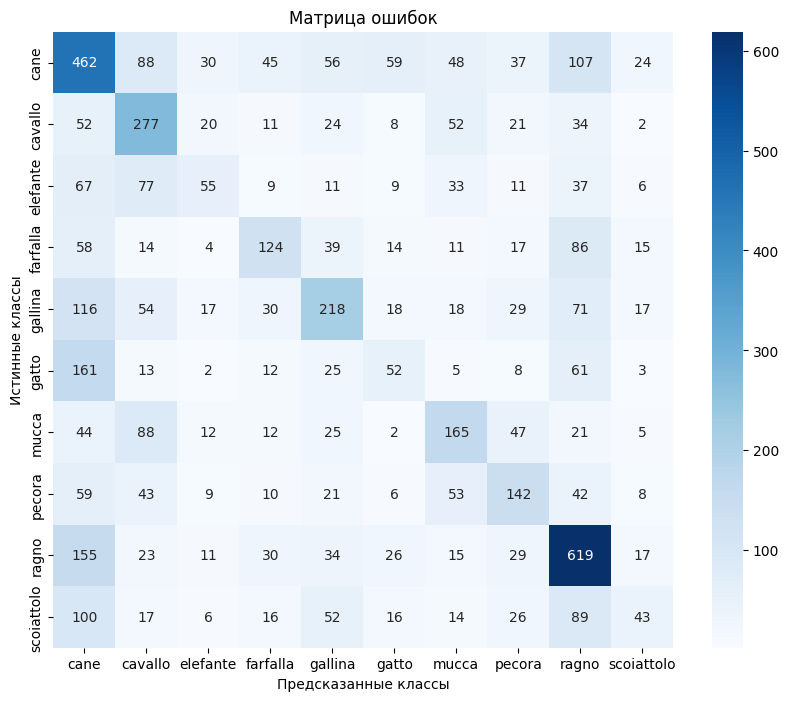

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_pred = preds.argmax(axis=1)
y_true = y_test.argmax(axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(labels_str), yticklabels=np.unique(labels_str))
plt.xlabel('Предсказанные классы')
plt.ylabel('Истинные классы')
plt.title('Матрица ошибок')
plt.show()

#### 7.3. Отобразим график обучения

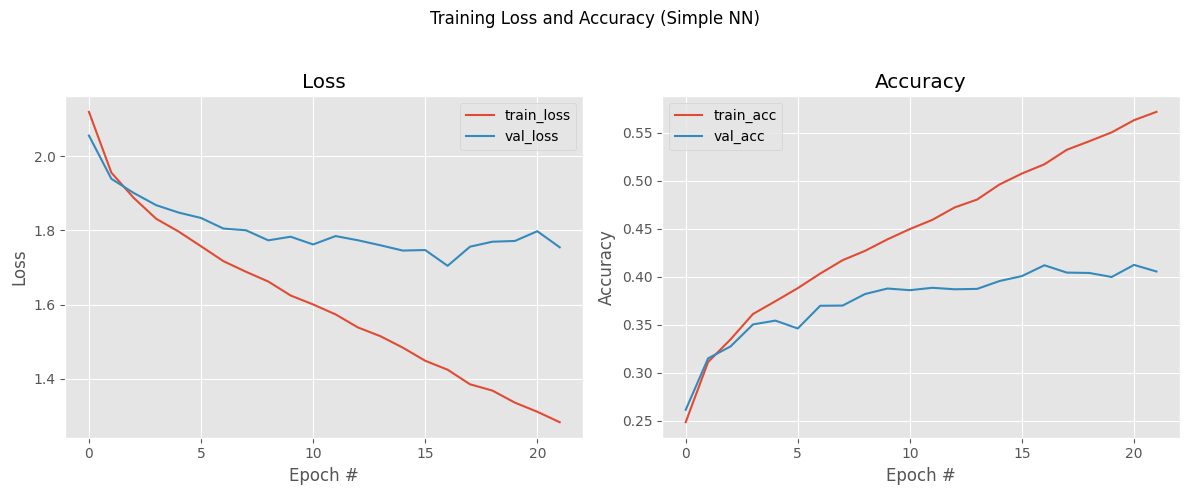

In [43]:
# Построение графиков потерь и точности в двух соседних графиках
# Автоматически вычисляем количество эпох из истории обучения
actual_epochs = len(H.history["loss"])
epochs_range = np.arange(0, actual_epochs)

plt.style.use("ggplot")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# График потерь (loss)
ax1.plot(epochs_range, H.history["loss"], label="train_loss")
ax1.plot(epochs_range, H.history["val_loss"], label="val_loss")
ax1.set_title("Loss")
ax1.set_xlabel("Epoch #")
ax1.set_ylabel("Loss")
ax1.legend()

# График точности (accuracy)
ax2.plot(epochs_range, H.history["accuracy"], label="train_acc")
ax2.plot(epochs_range, H.history["val_accuracy"], label="val_acc")
ax2.set_title("Accuracy")
ax2.set_xlabel("Epoch #")
ax2.set_ylabel("Accuracy")
ax2.legend()

plt.suptitle("Training Loss and Accuracy (Simple NN)")
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()

### 8. Сохранение модели и меток классов:

In [44]:
model_img.save('my_model.h5')
import pickle

with open('class_labels.pkl', 'wb') as f:
    pickle.dump(lb.classes_, f)

print(f"Сохранены классы: {lb.classes_}")

Сохранены классы: ['cane' 'cavallo' 'elefante' 'farfalla' 'gallina' 'gatto' 'mucca' 'pecora'
 'ragno' 'scoiattolo']


### 9. Проверка обученной модели пользовательскими данными:

#### 9.1. Импортируем необходимые библиотеки

In [45]:
pip install gradio

In [46]:
import gradio as gr
import pickle



#### 9.2. Реализуем функцию для предобработки входных данных в той же последовательности, что и при формировании обучающей выборки:

In [47]:
import tensorflow as tf

model_img = tf.keras.models.load_model('my_model.h5')
with open('class_labels.pkl', 'rb') as f:
    class_labels = pickle.load(f)

In [48]:
print(class_labels)

['cane' 'cavallo' 'elefante' 'farfalla' 'gallina' 'gatto' 'mucca' 'pecora'
 'ragno' 'scoiattolo']


#### 9.3. Определим функцию для осуществления прогноза по загруженной модели:

In [58]:
def predict_image(img):
    translate = {"cane": "dog", "cavallo": "horse", "elefante": "elephant", "farfalla": "butterfly", "gallina": "chicken", "gatto": "cat", "mucca": "cow", "pecora": "sheep", "scoiattolo": "squirrel", "ragno": "spider"}

    try:
        img_array = np.array(img)

        img_array = cv2.resize(img_array, (64, 64))
        img_array = img_array.astype("float32") / 255.0

        img_array = img_array.flatten().reshape(1, -1)

        predictions = model_img.predict(img_array, verbose=0)

        result = {}
        for i in range(len(class_labels)):
            label_it = class_labels[i]
            # Из translate вызываем английское название по итальянскому ключу
            label_en = translate.get(label_it, label_it)
            result[label_en] = float(predictions[0][i])

        return result
    except Exception as e:
        print(f"Ошибка при предсказании: {e}")
        return f"Error: {str(e)}"

### 10. Визуализируем интерфейс и произведем классификацию:

In [61]:
interface = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(type="numpy"),
    outputs=gr.Label(num_top_classes=3),
    live=True,
    title="Классификация изображений",
    description="Загрузите изображение, и модель предскажет его класс."
)

interface.launch(debug=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://e6bde98d8b09b849e5.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 421, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 56, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1159, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

Using existing dataset file at: .gradio/flagged/dataset1.csv
Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://e6bde98d8b09b849e5.gradio.live
